In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
def load_plet_data(filepath):
    from nexusformat.nexus import nxload
    
    data = nxload(str(filepath))
    entry_name = list(data.keys())[0]
    entry = data[entry_name]
    
    return entry

filepath = Path("/Users/shubhamshinde/Documents/Neutron Project /Data /benzene_260_360_inc.nxspe")
nxspe_entry = load_plet_data(filepath)

In [3]:
intensity = nxspe_entry['data/data'].nxvalue
energy_edges = nxspe_entry['data/energy'].nxvalue
energy = 0.5 * (energy_edges[:-1] + energy_edges[1:])

print(f"Data shape: {intensity.shape}")
print(f"Energy range: {energy[0]:.2f} to {energy[-1]:.2f} meV")

Data shape: (249, 320)
Energy range: -2.87 to 2.87 meV


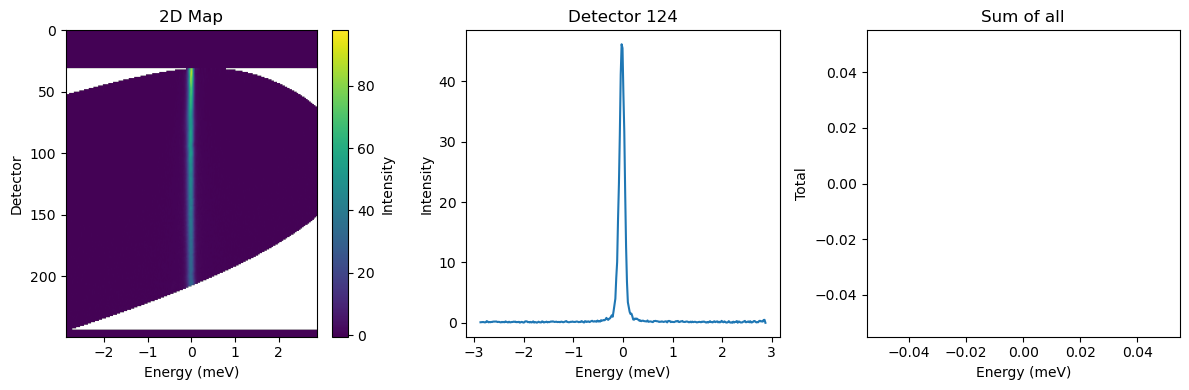

In [4]:
if intensity.shape[0] == len(energy):
    intensity = intensity.T



plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(intensity, aspect='auto', 
           extent=[energy.min(), energy.max(), intensity.shape[0], 0],
           cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Energy (meV)')
plt.ylabel('Detector')
plt.title('2D Map')




plt.subplot(1, 3, 2)
mid_idx = intensity.shape[0] // 2
plt.plot(energy, intensity[mid_idx, :])
plt.xlabel('Energy (meV)')
plt.ylabel('Intensity')
plt.title(f'Detector {mid_idx}')




plt.subplot(1, 3, 3)
total = np.sum(intensity, axis=0)
plt.plot(energy, total)
plt.xlabel('Energy (meV)')
plt.ylabel('Total')
plt.title('Sum of all')



plt.tight_layout()
plt.show()

In [5]:
zero_idx = np.argmin(np.abs(energy))
elastic = intensity[:, zero_idx]

print(f"Total counts: {np.sum(intensity):.0f}")
print(f"Mean: {np.mean(intensity):.2f}")
print(f"Max: {np.max(intensity):.1f}")
print(f"Elastic fraction: {np.sum(elastic)/np.sum(intensity)*100:.1f}%")
print(f"Energy step: {energy[1]-energy[0]:.4f} meV")

Total counts: nan
Mean: nan
Max: nan
Elastic fraction: nan%
Energy step: 0.0180 meV


/var/folders/qx/4fpd5mln61bcz8xrf8x5wjch0000gn/T/ipykernel_1280/4224996532.py:21: RuntimeWarning: invalid value encountered in divide
  spec = intensity[idx, :] / np.max(intensity[idx, :])


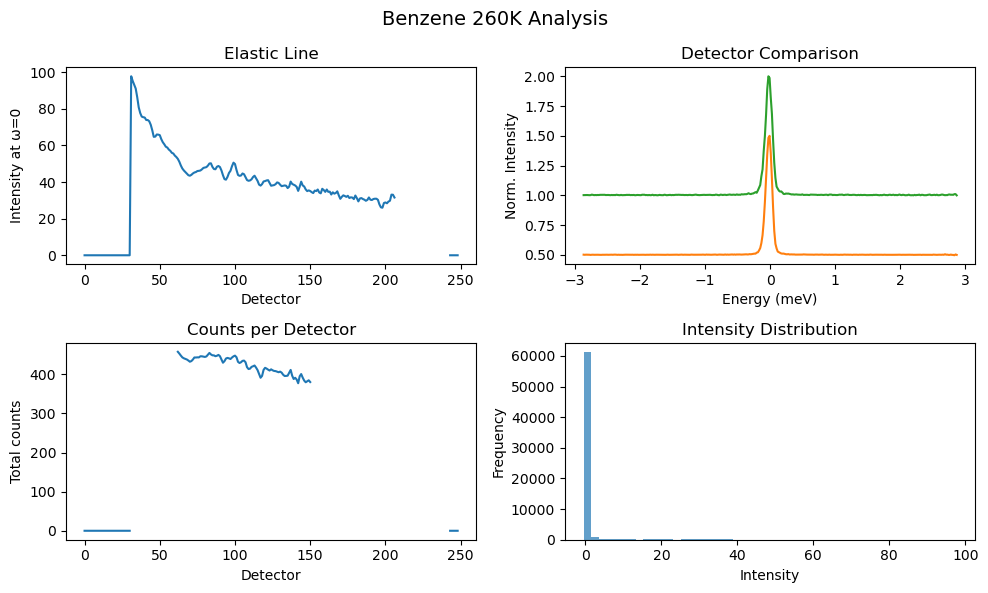

In [6]:
plt.figure(figsize=(10, 6))




# Plot 1: Elastic line
plt.subplot(2, 2, 1)
plt.plot(range(len(elastic)), elastic)
plt.xlabel('Detector')
plt.ylabel('Intensity at ω=0')
plt.title('Elastic Line')





# Plot 2: Multiple detectors
plt.subplot(2, 2, 2)
det_indices = [0, intensity.shape[0]//4, intensity.shape[0]//2, 3*intensity.shape[0]//4]
for i, idx in enumerate(det_indices):
    spec = intensity[idx, :] / np.max(intensity[idx, :])
    plt.plot(energy, spec + i*0.5, label=f'Det {idx}')
plt.xlabel('Energy (meV)')
plt.ylabel('Norm. Intensity')
plt.title('Detector Comparison')





# Plot 3: Integrated per detector
plt.subplot(2, 2, 3)
integrated = np.sum(intensity, axis=1)
plt.plot(range(len(integrated)), integrated)
plt.xlabel('Detector')
plt.ylabel('Total counts')
plt.title('Counts per Detector')





# Plot 4: Energy histogram
plt.subplot(2, 2, 4)
plt.hist(intensity.flatten(), bins=50, alpha=0.7)
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.title('Intensity Distribution')

plt.suptitle('Benzene 260K Analysis', fontsize=14)
plt.tight_layout()
plt.show()

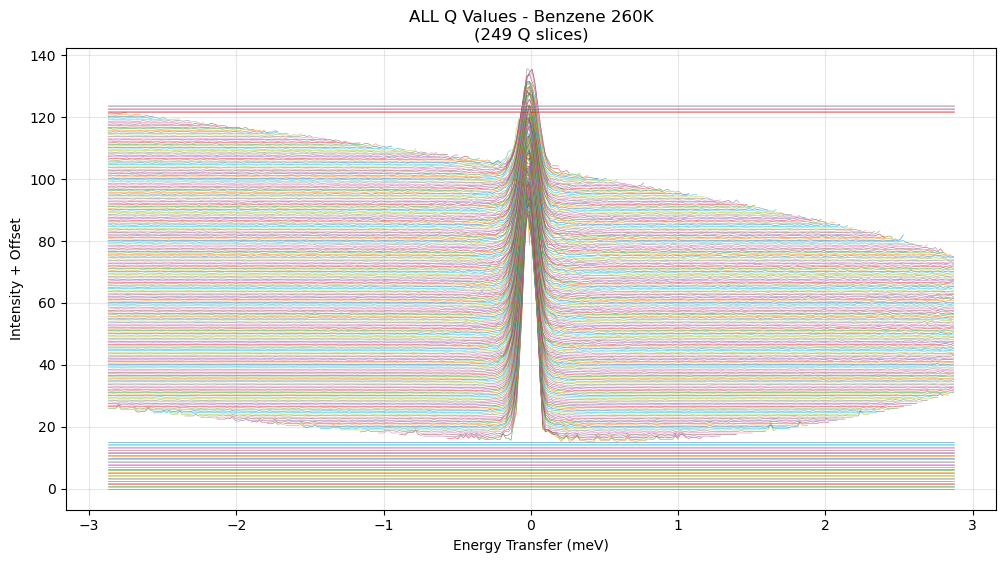

In [7]:
plt.figure(figsize=(12, 6))

for i in range(intensity.shape[0]):
    plt.plot(energy, intensity[i, :] + i*0.5, linewidth=0.5, alpha=0.7)

plt.xlabel('Energy Transfer (meV)')
plt.ylabel('Intensity + Offset')
plt.title(f'ALL Q Values - Benzene 260K\n({intensity.shape[0]} Q slices)')
plt.grid(True, alpha=0.3)
plt.show()

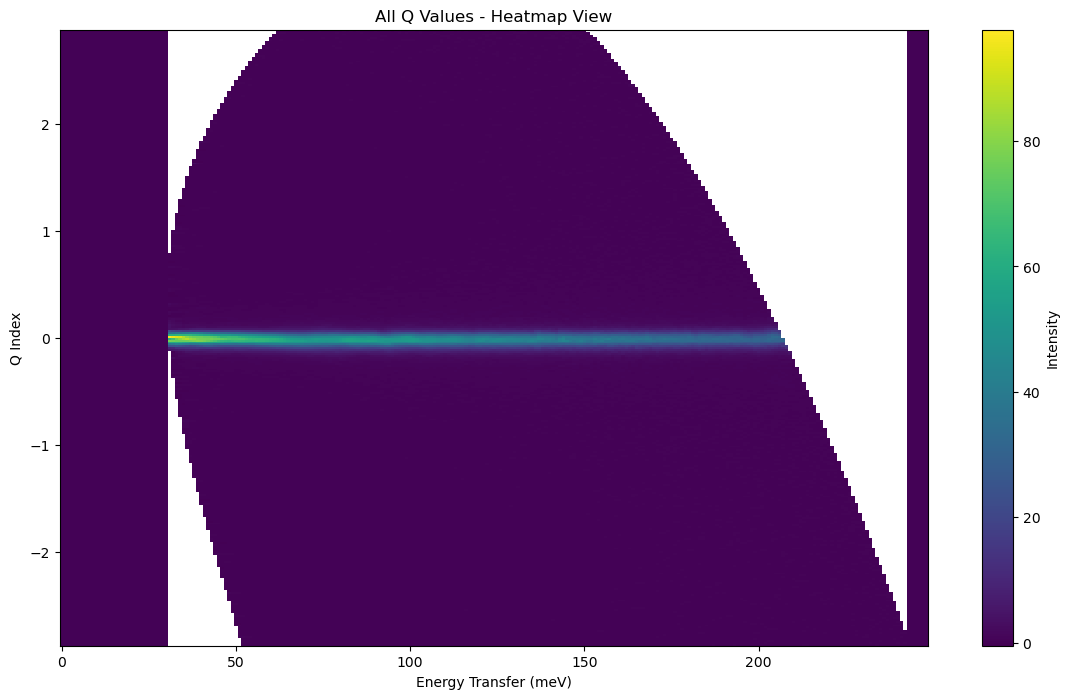

In [8]:
plt.figure(figsize=(14, 8))


Q_indices = np.arange(intensity.shape[0])
Q_grid, E_grid = np.meshgrid(energy, Q_indices, indexing='ij')

plt.pcolormesh(E_grid, Q_grid, intensity.T, shading='auto', cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Energy Transfer (meV)')
plt.ylabel('Q Index')
plt.title('All Q Values - Heatmap View')
plt.show()

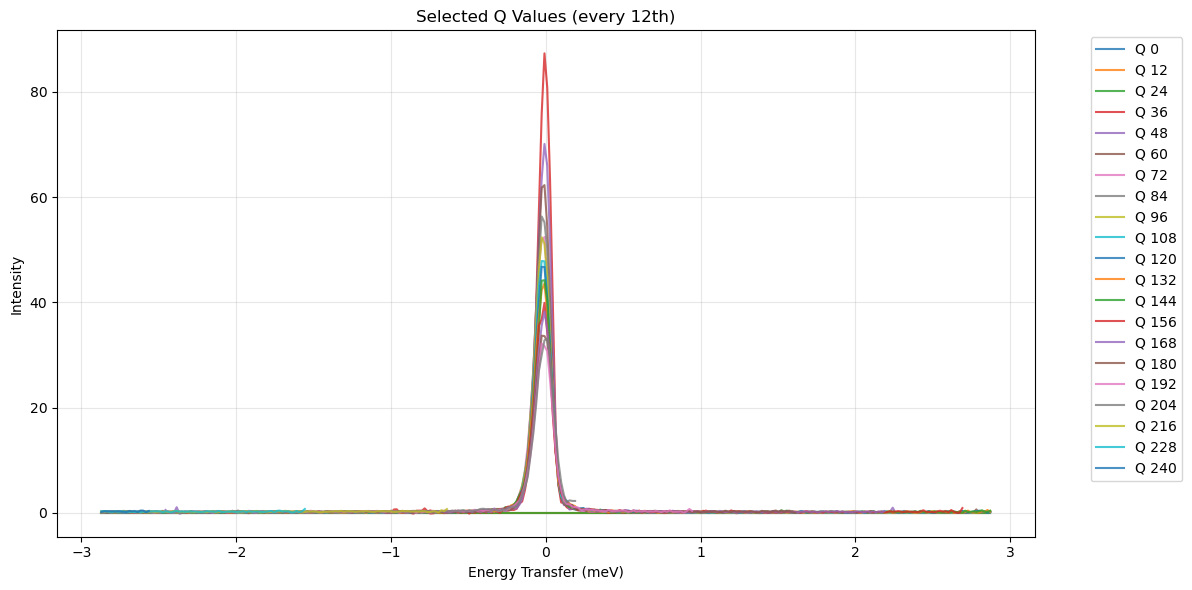

Showing 21 out of 249 Q values


In [9]:
plt.figure(figsize=(12, 6))

step = max(1, intensity.shape[0] // 20)  
q_indices = range(0, intensity.shape[0], step)

for i in q_indices:
    plt.plot(energy, intensity[i, :], linewidth=1.5, alpha=0.8, label=f'Q {i}')

plt.xlabel('Energy Transfer (meV)')
plt.ylabel('Intensity')
plt.title(f'Selected Q Values (every {step}th)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



print(f"Showing {len(q_indices)} out of {intensity.shape[0]} Q values")

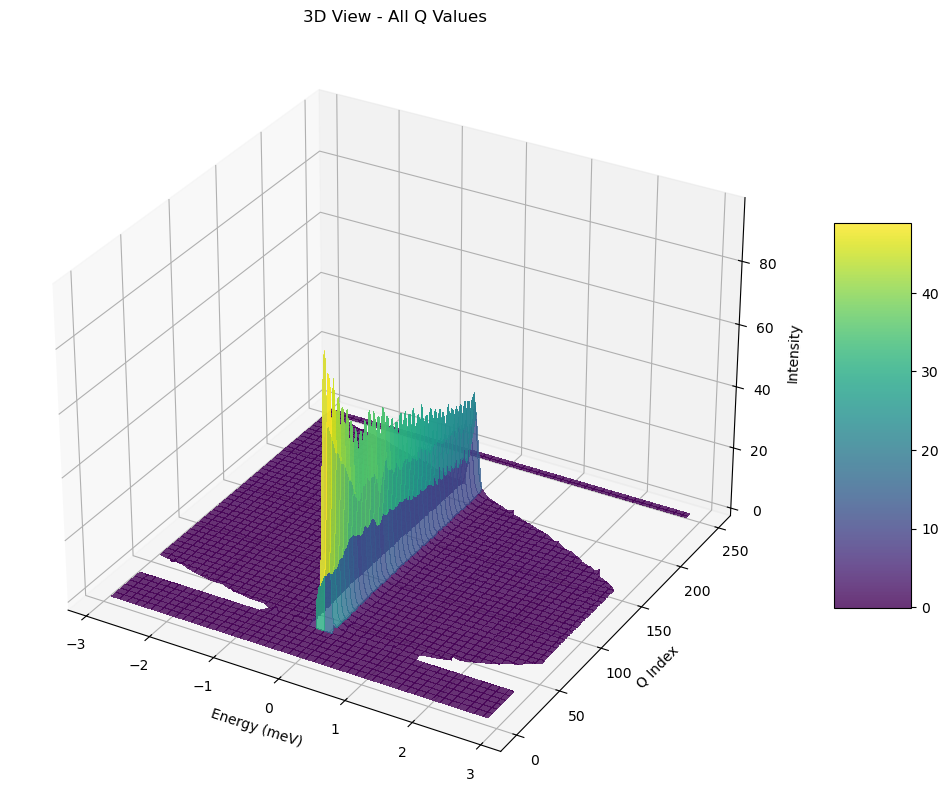

In [10]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')


X, Y = np.meshgrid(energy, np.arange(intensity.shape[0]))


surf = ax.plot_surface(X, Y, intensity, cmap='viridis', 
                      linewidth=0, antialiased=False, alpha=0.8)

ax.set_xlabel('Energy (meV)')
ax.set_ylabel('Q Index')
ax.set_zlabel('Intensity')
ax.set_title('3D View - All Q Values')
plt.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

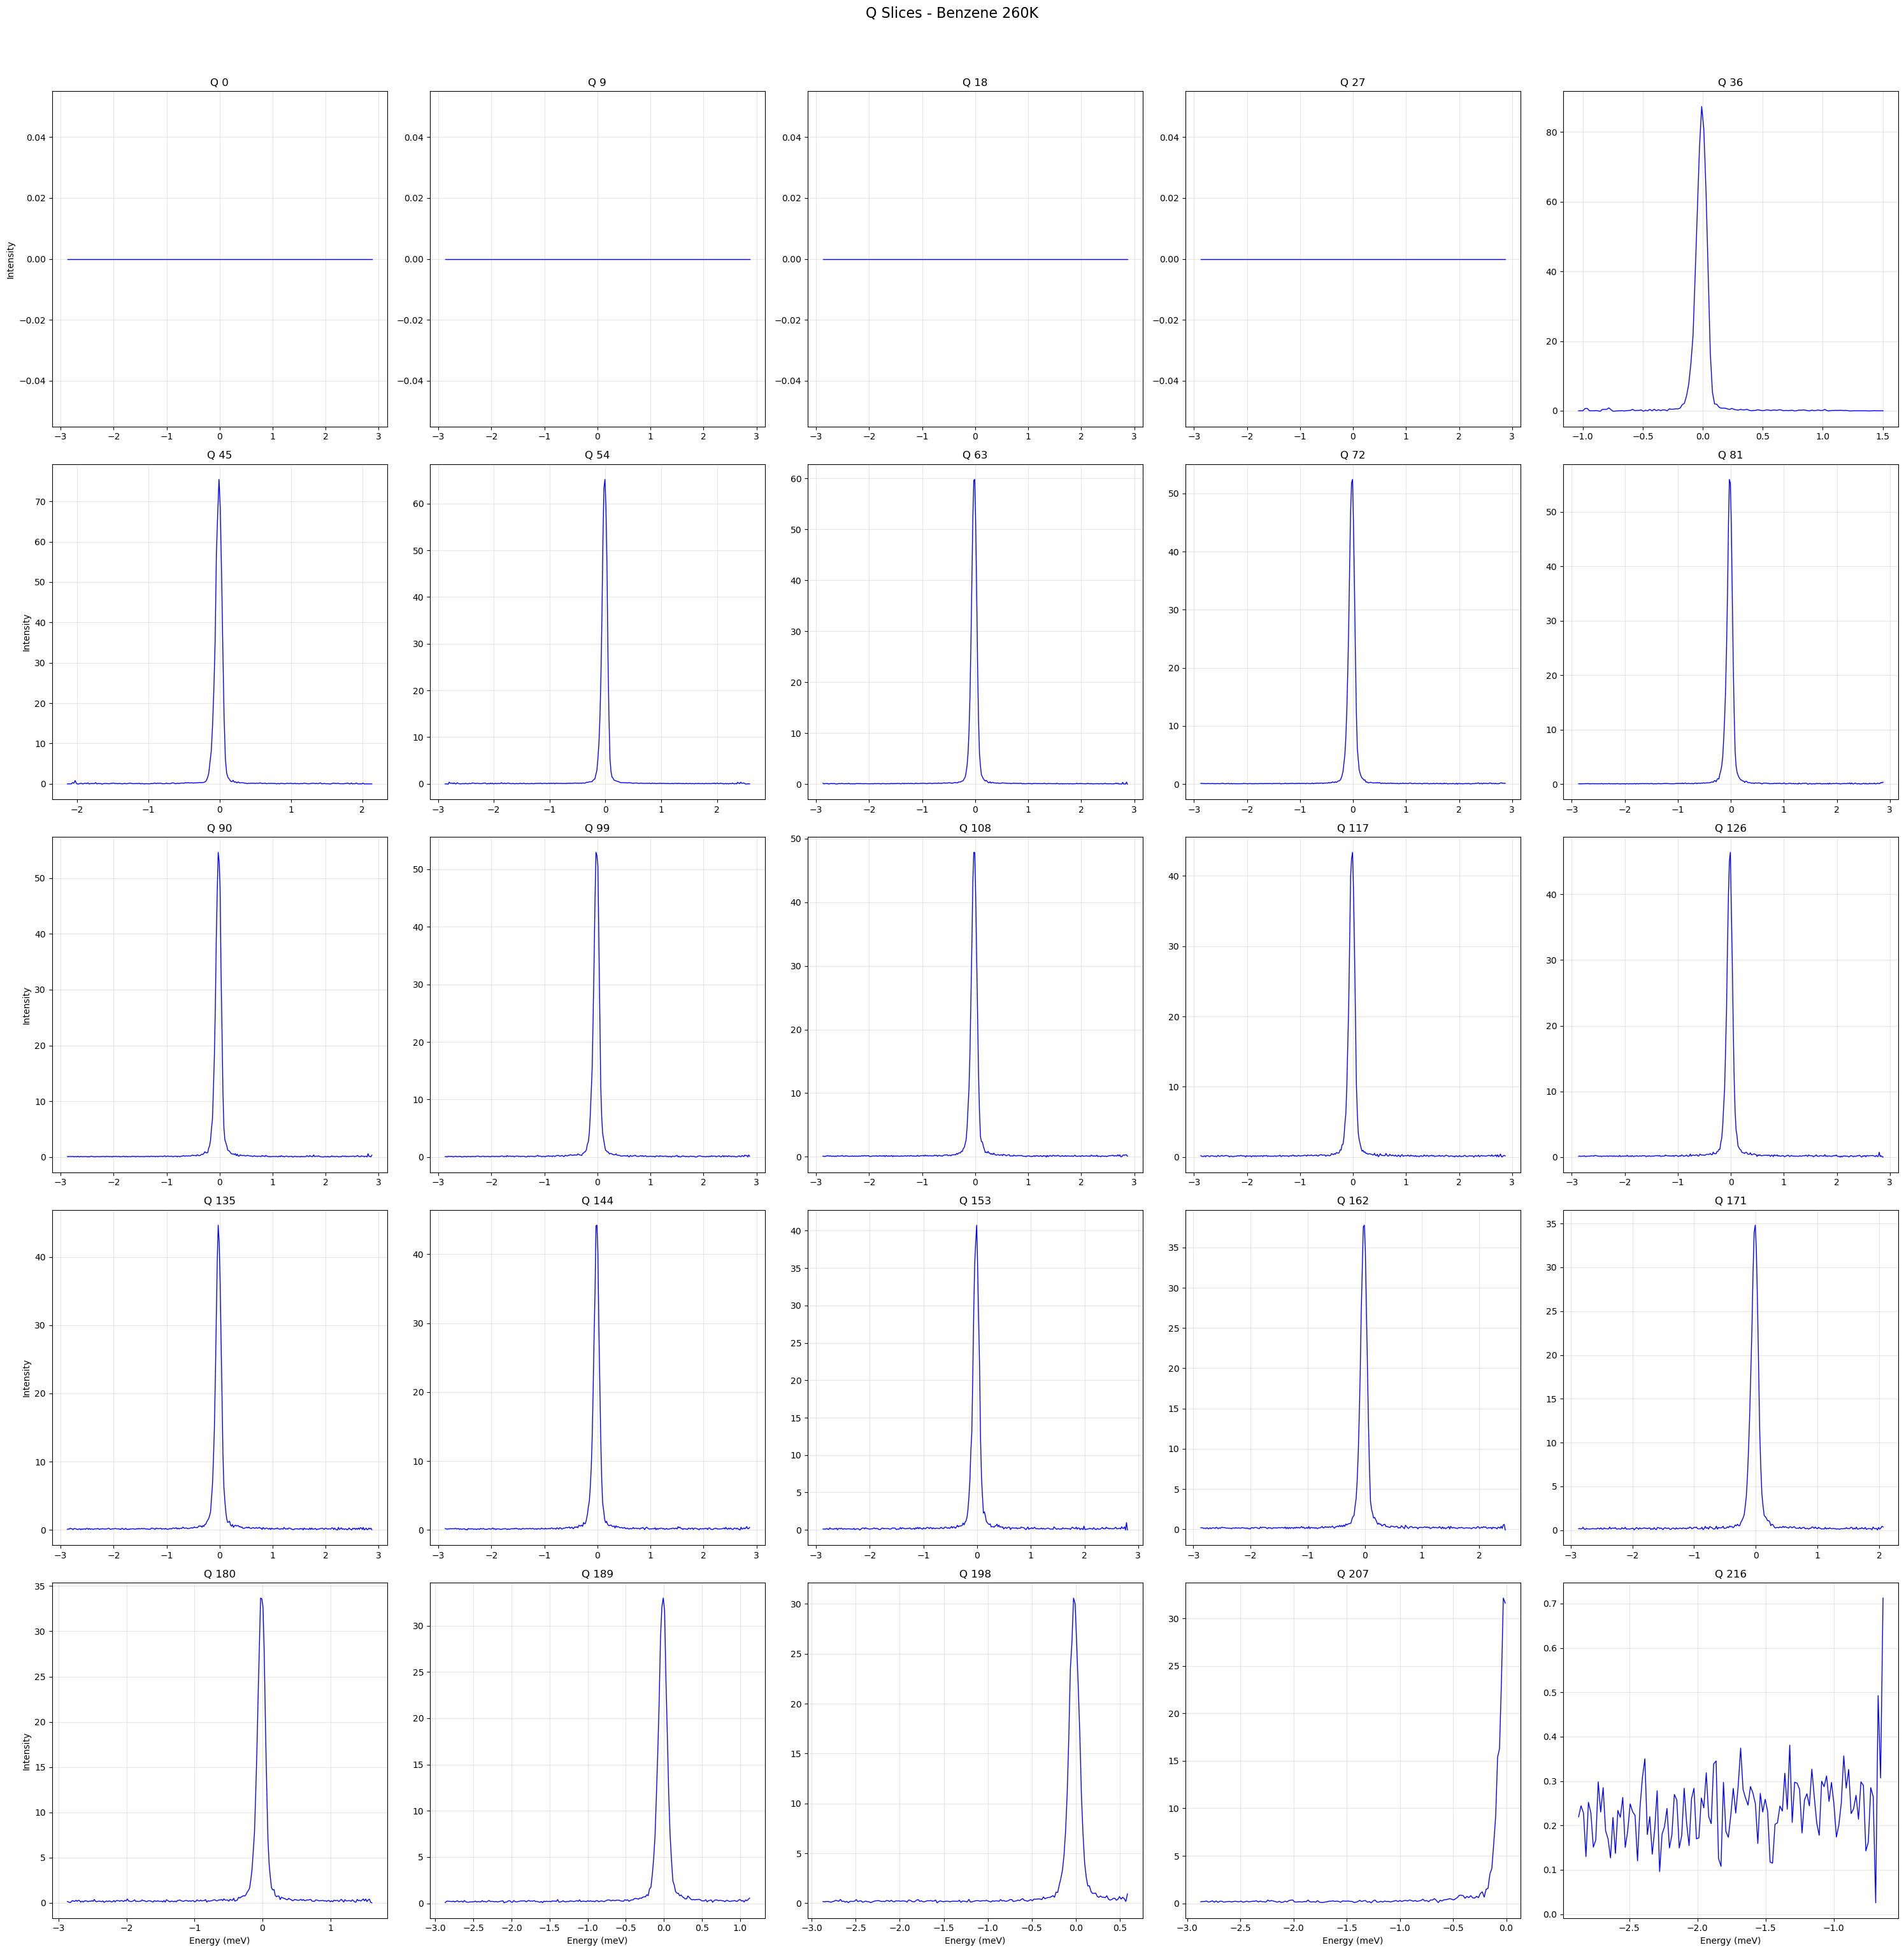

In [11]:
plt.figure(figsize=(30, 30))

n_rows = 5
n_cols = 5
total_plots = n_rows * n_cols
step = max(1, intensity.shape[0] // total_plots)

plot_idx = 0
for row in range(n_rows):
    for col in range(n_cols):
        plt.subplot(n_rows, n_cols, plot_idx + 1)
        
        q_idx = plot_idx * step
        if q_idx < intensity.shape[0]:
            plt.plot(energy, intensity[q_idx, :], 'b-', linewidth=1)
            plt.title(f'Q {q_idx}')
            plt.grid(True, alpha=0.3)
            
            if row == n_rows - 1:
                plt.xlabel('Energy (meV)')
            if col == 0:
                plt.ylabel('Intensity')
        
        plot_idx += 1

plt.suptitle('Q Slices - Benzene 260K', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
try:
    from ipywidgets import interact, IntSlider
    
    def plot_q_slice(q_index):
        plt.figure(figsize=(10, 6))
        plt.plot(energy, intensity[q_index, :], 'b-', linewidth=2)
        plt.fill_between(energy, 0, intensity[q_index, :], alpha=0.3)
        plt.xlabel('Energy Transfer (meV)')
        plt.ylabel('Intensity')
        plt.title(f'Q Slice {q_index}')
        plt.grid(True, alpha=0.3)
        
  
        stats_text = f"Max: {np.max(intensity[q_index, :]):.1f}\n"
        stats_text += f"Sum: {np.sum(intensity[q_index, :]):.0f}\n"
        stats_text += f"Mean: {np.mean(intensity[q_index, :]):.2f}"
        
        plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        plt.show()
    
    interact(plot_q_slice, 
             q_index=IntSlider(min=0, max=intensity.shape[0]-1, 
                              step=1, value=intensity.shape[0]//2,
                              description='Q Index:'))
    
except ImportError:
    print("install ipywidgets")

interactive(children=(IntSlider(value=124, description='Q Index:', max=248), Output()), _dom_classes=('widget-…

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import pytensor.tensor as pt
from pathlib import Path
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

In [14]:
def load_plet_data(filepath):
    """Load data from nxspe file"""
    from nexusformat.nexus import nxload
    data = nxload(str(filepath))
    entry_name = list(data.keys())[0]
    entry = data[entry_name]
    return entry


class QENSModels:
    """Collection of physical models for QENS analysis"""
    
    @staticmethod
    def chudley_elliott_model(q, D, tau):
        """
        Chudley-Elliott jump diffusion model
        Γ(q) = (ħ/τ) * (1 - exp(-q²Dτ))
        """
        return (1/tau) * (1 - pt.exp(-q**2 * D * tau))
    
    @staticmethod
    def singwi_sjolander_model(q, D, tau, l):
        """
        Singwi-Sjölander model with vibrational component
        """
        translational = (1/tau) * (q**2 * D) / (1 + q**2 * D * tau)
        vibrational = pt.exp(-q**2 * l**2 / 3)
        return translational * vibrational
    
    @staticmethod
    def hall_ross_model(q, D, tau, a):
        """
        Hall-Ross model for confined diffusion
        a: confinement radius
        """
        x = q * a
        # Using analytical approximation for spherical confinement
        j0_squared = pt.switch(pt.eq(x, 0), 1.0, (pt.sin(x) / x)**2)
        return (1/tau) * (1 - j0_squared) / (1 + q**2 * D * tau)

In [ ]:

def prepare_data_for_fitting_optimized(intensity, energy, 
                                        max_q_points=12, 
                                        energy_range=(-0.8, 0.8), 
                                        bin_energy=True,
                                        normalize_method='area'):
    
    """
    Optimized data preparation with dimensionality reduction
    """

    if energy_range is not None:
        energy_mask = (energy >= energy_range[0]) & (energy <= energy_range[1])
        energy = energy[energy_mask]
        intensity = intensity[:, energy_mask]
    

    q_step = max(1, intensity.shape[0] // max_q_points)
    q_indices = list(range(0, intensity.shape[0], q_step))[:max_q_points]
    

    if bin_energy and len(energy) > 60:
        target_points = 50
        bin_factor = max(1, len(energy) // target_points)
        
        if bin_factor > 1:
            n_energy_bins = len(energy) // bin_factor
            energy_binned = np.zeros(n_energy_bins)
            intensity_binned = np.zeros((len(q_indices), n_energy_bins))
            
            for i in range(n_energy_bins):
                start = i * bin_factor
                end = min((i + 1) * bin_factor, len(energy))
                energy_binned[i] = np.mean(energy[start:end])
                intensity_binned[:, i] = np.mean(
                    intensity[np.ix_(q_indices, np.arange(start, end))], axis=1
                )
            
            energy = energy_binned
            intensity = intensity_binned
        else:
            intensity = intensity[q_indices, :]
    else:
        intensity = intensity[q_indices, :]
    

    q_values = np.linspace(0.3, 1.9, len(q_indices))

    spectra = []
    scale_factors = []
    
    for i in range(len(q_indices)):
        spectrum = intensity[i, :].copy()
        spectrum = np.maximum(spectrum, 1e-10) 
        
        if normalize_method == 'area':
            scale = np.sum(spectrum)
            if scale > 0:
                spectrum = spectrum / scale
            scale_factors.append(scale)
        else:  # peak normalization
            scale = np.max(spectrum)
            if scale > 0:
                spectrum = spectrum / scale
            scale_factors.append(scale)
        
        spectra.append(spectrum)
    
    return {
        'q_values': q_values,
        'energy': energy,
        'spectra': np.array(spectra),
        'q_indices': q_indices,
        'scale_factors': np.array(scale_factors)
    }



In [ ]:
def create_optimized_qens_model(q_values, energy, spectra, model_type='chudley_elliott'):
    """
    Optimized model with fewer parameters and smarter priors
    """
    n_q = len(q_values)
    n_energy = len(energy)
    

    hbar = 0.658212  # meV·ps
    omega = energy / hbar
    
    with pm.Model() as model:
        
        D = pm.Lognormal('D', mu=np.log(0.1), sigma=0.5)
        tau = pm.Lognormal('tau', mu=np.log(1.0), sigma=0.5)
        
        
        if model_type == 'chudley_elliott':
            gamma_q = QENSModels.chudley_elliott_model(q_values, D, tau)
        
        elif model_type == 'singwi_sjolander':
            l = pm.Lognormal('l', mu=np.log(1.0), sigma=0.3)
            gamma_q = QENSModels.singwi_sjolander_model(q_values, D, tau, l)
        
        elif model_type == 'hall_ross':
            a = pm.Lognormal('a', mu=np.log(3.0), sigma=0.3)
            gamma_q = QENSModels.hall_ross_model(q_values, D, tau, a)
        
        else:
            raise ValueError(f"Unknown model type: {model_type}")
        
        
        amplitude = pm.HalfNormal('amplitude', sigma=5.0)
        
        
        background = pm.Normal('background', mu=0, sigma=0.05)
        
        
        theoretical_list = []
        for i in range(n_q):
            
            lorentzian = amplitude * (gamma_q[i] * hbar / np.pi) / (energy**2 + (gamma_q[i] * hbar)**2)
            
            
            lorentzian = lorentzian + background
            
            
            lorentzian = pm.math.maximum(lorentzian, 1e-10)
            lorentzian = lorentzian / pt.sum(lorentzian)
            
            theoretical_list.append(lorentzian)
        
        theoretical_spectra = pt.stack(theoretical_list, axis=0)
        
        
        sigma = pm.HalfNormal('sigma', sigma=0.05)
        obs = pm.Normal('obs', mu=theoretical_spectra, sigma=sigma,
                        observed=spectra)
        
   
        pm.Deterministic('jump_distance', pt.sqrt(6 * D * tau))
    
    return model


In [ ]:
def progressive_fit_qens(data, model_type='chudley_elliott', 
                         quick_n_samples=2000,
                         short_draws=300, short_tune=200,
                         full_draws=500, full_tune=300):
    """
    Progressive fitting strategy with fixed start parameter handling
    """
    print(f"  Step 1: Quick ADVI...")
    
    
    model_quick = create_optimized_qens_model(data['q_values'], data['energy'], data['spectra'], model_type)
    
    with model_quick:
        approx = pm.fit(n=quick_n_samples, method='advi', 
                        obj_optimizer=pm.adagrad(learning_rate=0.01),
                        progressbar=False)
        
        
        start_dict = {}
        for var in model_quick.value_vars:
            name = var.name
            
            samples = approx.sample(draws=100)
            if name in samples.posterior:
                start_dict[name] = float(samples.posterior[name].values.mean())
    
    
    print(f"  Step 2: Short MCMC...")
    model_short = create_optimized_qens_model(
        data['q_values'], data['energy'], data['spectra'], model_type
    )
    
    with model_short:
        try:
            trace_short = pm.sample(
                draws=short_draws,
                tune=short_tune,
                chains=2,
                start=start_dict,  
                progressbar=True,
                init='adapt_diag',
                target_accept=0.8,
                return_inferencedata=True
            )
            

            try:
                rhat = az.rhat(trace_short)
                max_rhat = 0
                for v in rhat.values():
                    if hasattr(v, 'values') and v.values.size > 0:
                        max_rhat = max(max_rhat, v.values.max())
            except:
                max_rhat = 1.1
            
            if max_rhat < 1.05:
                print(f"  Converged! Using short trace (max rhat={max_rhat:.3f})")
                trace = trace_short
            else:
                # Step 3: Full MCMC if needed
                print(f"  Step 3: Full MCMC (max rhat={max_rhat:.3f})...")
                trace = pm.sample(
                    draws=full_draws,
                    tune=full_tune,
                    chains=2,
                    start=start_dict,
                    cores=2,
                    progressbar=True,
                    target_accept=0.85,
                    return_inferencedata=True
                )
        
        except Exception as e:
            print(f"  MCMC failed: {e}")
            print("  Falling back to ADVI samples...")
            trace = approx.sample(draws=1000)
    
    summary = az.summary(trace, hdi_prob=0.95)
    
    return trace, summary



In [ ]:

def plot_fit_results(data, trace, model_type, n_plots=6):
    """Plot fitting results"""
    n_q = len(data['q_values'])
    plot_indices = np.linspace(0, n_q-1, min(n_plots, n_q)).astype(int)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, plot_idx in enumerate(plot_indices):
        if i >= len(axes):
            break
        ax = axes[i]
        
        # Plot data
        ax.plot(data['energy'], data['spectra'][plot_idx], 'ko', 
                markersize=3, alpha=0.5, label='Data')
        
        # Plot median fit if available
        if hasattr(trace, 'posterior') and 'obs' in trace.posterior:
            try:
                obs_samples = trace.posterior['obs'].values[:, :, plot_idx, :]
                mean_spectrum = obs_samples.mean(axis=(0, 1))
                ax.plot(data['energy'], mean_spectrum, 'r-', 
                        linewidth=2, label='Posterior mean')
            except:
                pass
        
        ax.set_xlabel('Energy Transfer (meV)')
        ax.set_ylabel('Intensity')
        ax.set_title(f'Q = {data["q_values"][plot_idx]:.2f} Å⁻¹')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for j in range(len(plot_indices), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle(f'{model_type.replace("_", " ").title()} Model Fit', 
                 y=1.02, fontsize=14)
    plt.show()


def plot_parameter_distributions(trace, model_type):
    """Plot posterior distributions of key parameters"""
    # Key parameters to plot
    vars_to_plot = ['D', 'tau', 'jump_distance']
    
    if model_type == 'singwi_sjolander':
        vars_to_plot.append('l')
    elif model_type == 'hall_ross':
        vars_to_plot.append('a')
    
    # Check which variables exist
    available_vars = []
    for var in vars_to_plot:
        if hasattr(trace, 'posterior') and var in trace.posterior:
            available_vars.append(var)
    
    if not available_vars:
        print("No parameters to plot")
        return
    
    n_vars = len(available_vars)
    n_cols = min(3, n_vars)
    n_rows = (n_vars + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    units = {
        'D': 'Å²/ps',
        'tau': 'ps',
        'jump_distance': 'Å',
        'l': 'Å',
        'a': 'Å'
    }
    
    for i, var in enumerate(available_vars):
        ax = axes[i]
        
        # Get samples
        samples = trace.posterior[var].values.flatten()
        samples = samples[np.isfinite(samples)]
        
        if len(samples) > 0:
            # Plot histogram
            ax.hist(samples, bins=30, density=True, alpha=0.7, 
                    color='steelblue', edgecolor='black')
            
            # Add statistics
            mean = np.mean(samples)
            median = np.median(samples)
            hdi_low, hdi_high = np.percentile(samples, [2.5, 97.5])
            
            ax.axvline(mean, color='red', linestyle='--', 
                      label=f'Mean: {mean:.3f}')
            ax.axvline(median, color='green', linestyle='--',
                      label=f'Median: {median:.3f}')
            ax.axvspan(hdi_low, hdi_high, alpha=0.2, color='red',
                      label='95% HDI')
            
            unit = units.get(var, '')
            ax.set_xlabel(f'{var} ({unit})')
            ax.set_ylabel('Density')
            ax.set_title(f'Posterior: {var}')
            ax.legend(fontsize=8)
    
    # Hide unused subplots
    for j in range(len(available_vars), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle(f'{model_type.replace("_", " ").title()} Parameter Distributions', 
                 y=1.02, fontsize=14)
    plt.show()


def plot_hwhm_vs_q2(trace, data, model_type):
    """Plot HWHM vs Q² to visualize diffusion behavior"""
    if not hasattr(trace, 'posterior') or 'D' not in trace.posterior:
        print("Cannot plot HWHM - missing parameters")
        return
    
    q_values = data['q_values']
    q2 = q_values**2
    hbar = 0.658212  # meV·ps
    
    # Get posterior samples
    D_samples = trace.posterior['D'].values.flatten()
    tau_samples = trace.posterior['tau'].values.flatten()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot a subset of posterior draws
    n_samples_to_plot = min(50, len(D_samples))
    indices = np.random.choice(len(D_samples), n_samples_to_plot, replace=False)
    
    for idx in indices:
        D = D_samples[idx]
        tau = tau_samples[idx]
        
        if model_type == 'chudley_elliott':
            hwhm = (1/tau) * (1 - np.exp(-q2 * D * tau))
        elif model_type == 'singwi_sjolander' and 'l' in trace.posterior:
            l_samples = trace.posterior['l'].values.flatten()
            l = l_samples[idx % len(l_samples)]
            hwhm = (1/tau) * (q2 * D) / (1 + q2 * D * tau) * np.exp(-q2 * l**2 / 3)
        elif model_type == 'hall_ross' and 'a' in trace.posterior:
            a_samples = trace.posterior['a'].values.flatten()
            a = a_samples[idx % len(a_samples)]
            x = q_values * a
            j0_squared = (np.sin(x) / x)**2
            hwhm = (1/tau) * (1 - j0_squared) / (1 + q2 * D * tau)
        else:
            hwhm = (1/tau) * (1 - np.exp(-q2 * D * tau))
        
        ax.plot(q2, hwhm * hbar, 'b-', alpha=0.1)
    
    # Plot median line
    D_median = np.median(D_samples)
    tau_median = np.median(tau_samples)
    
    if model_type == 'chudley_elliott':
        hwhm_median = (1/tau_median) * (1 - np.exp(-q2 * D_median * tau_median))
    elif model_type == 'singwi_sjolander' and 'l' in trace.posterior:
        l_median = np.median(trace.posterior['l'].values.flatten())
        hwhm_median = (1/tau_median) * (q2 * D_median) / (1 + q2 * D_median * tau_median) * np.exp(-q2 * l_median**2 / 3)
    elif model_type == 'hall_ross' and 'a' in trace.posterior:
        a_median = np.median(trace.posterior['a'].values.flatten())
        x = q_values * a_median
        j0_squared = (np.sin(x) / x)**2
        hwhm_median = (1/tau_median) * (1 - j0_squared) / (1 + q2 * D_median * tau_median)
    else:
        hwhm_median = (1/tau_median) * (1 - np.exp(-q2 * D_median * tau_median))
    
    ax.plot(q2, hwhm_median * hbar, 'r-', linewidth=2, label='Median fit')
    
    ax.set_xlabel('Q² (Å⁻²)')
    ax.set_ylabel('HWHM (meV)')
    ax.set_title(f'{model_type.replace("_", " ").title()}: HWHM vs Q²')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()


In [ ]:
def accelerated_qens_analysis(intensity, energy, 
                               max_q_points=12,
                               models=['chudley_elliott']):

    start_time = time.time()
    
    
    # Step 1: Prepare optimized data
    print("\n[1/3] Preparing optimized data...")
    data = prepare_data_for_fitting_optimized(
        intensity, energy,
        max_q_points=max_q_points,
        energy_range=(-0.6, 0.6),  # Focus on quasielastic region
        bin_energy=True,
        normalize_method='area'
    )
    
    print(f"   Data shape: {data['spectra'].shape}")
    print(f"   Q points: {len(data['q_values'])}")
    print(f"   Energy points: {len(data['energy'])}")
    
    # Step 2: Fit models
    print("\n[2/3] Fitting models...")
    results = {}
    
    for model_type in models:
        print(f"\n   {'='*50}")
        print(f"   Fitting {model_type.replace('_', ' ').title()}")
        print(f"   {'='*50}")
        
        try:
            model_start = time.time()
            
            # Use progressive fitting
            trace, summary = progressive_fit_qens(
                data, model_type,
                quick_n_samples=2000,
                short_draws=300,
                short_tune=200,
                full_draws=500,
                full_tune=300
            )
            
            model_time = time.time() - model_start
            results[model_type] = (trace, summary)
            
            # Extract key parameters
            if 'D' in summary.index:
                D = summary.loc['D', 'mean']
                D_std = summary.loc['D', 'sd']
                
                if 'jump_distance' in summary.index:
                    J = summary.loc['jump_distance', 'mean']
                    J_std = summary.loc['jump_distance', 'sd']
                else:
                    # Calculate J from samples if not in summary
                    if hasattr(trace, 'posterior') and 'jump_distance' in trace.posterior:
                        J_samples = trace.posterior['jump_distance'].values.flatten()
                        J = np.mean(J_samples)
                        J_std = np.std(J_samples)
                    else:
                        J = np.nan
                        J_std = np.nan
                
                print(f"\n   Results ({model_time:.1f}s):")
                print(f"     D  = {D:.4f} ± {D_std:.4f} Å²/ps")
                print(f"     J  = {J:.4f} ± {J_std:.4f} Å")
                
                if model_type == 'singwi_sjolander' and 'l' in summary.index:
                    l = summary.loc['l', 'mean']
                    print(f"     l  = {l:.4f} ± {summary.loc['l', 'sd']:.4f} Å")
                elif model_type == 'hall_ross' and 'a' in summary.index:
                    a = summary.loc['a', 'mean']
                    print(f"     a  = {a:.4f} ± {summary.loc['a', 'sd']:.4f} Å")
            
        except Exception as e:
            print(f"   Error: {e}")
            import traceback
            traceback.print_exc()
    
    # Step 3: Visualize results
    print("\n[3/3] Generating visualizations...")
    
    for model_type, (trace, summary) in results.items():
        print(f"\n   Plotting {model_type}...")
        plot_fit_results(data, trace, model_type)
        plot_parameter_distributions(trace, model_type)
        plot_hwhm_vs_q2(trace, data, model_type)
    
    # Summary comparison
    print("\n" + "="*70)
    print("SUMMARY: Diffusion Parameters Comparison")
    print("="*70)
    
    comparison_data = []
    for model_type, (trace, summary) in results.items():
        if 'D' in summary.index:
            D_str = f"{summary.loc['D', 'mean']:.4f} ± {summary.loc['D', 'sd']:.4f}"
            
            if 'jump_distance' in summary.index:
                J_str = f"{summary.loc['jump_distance', 'mean']:.3f} ± {summary.loc['jump_distance', 'sd']:.3f}"
            else:
                J_str = "N/A"
            
            if 'tau' in summary.index:
                tau_str = f"{summary.loc['tau', 'mean']:.2f} ± {summary.loc['tau', 'sd']:.2f}"
            else:
                tau_str = "N/A"
            
            comparison_data.append({
                'Model': model_type.replace('_', ' ').title(),
                'D (Å²/ps)': D_str,
                'J (Å)': J_str,
                'τ (ps)': tau_str
            })
    
    if comparison_data:
        df = pd.DataFrame(comparison_data)
        print(df.to_string(index=False))
    
    total_time = time.time() - start_time
    print(f"\nTotal analysis time: {total_time:.1f} seconds")
    
    return results, data




In [ ]:
def quick_estimate_qens(intensity, energy):
    """
    Ultra-fast mode for quick estimates (1-2 minutes)
    """

    # Minimal data preparation
    data = prepare_data_for_fitting_optimized(
        intensity, energy,
        max_q_points=8,           # Only 8 Q points
        energy_range=(-0.5, 0.5), # Narrow energy range
        bin_energy=True,
        normalize_method='peak'
    )
    
    # Quick ADVI only for Chudley-Elliott model
    model_type = 'chudley_elliott'
    
    print(f"\nFitting {model_type} with ADVI...")
    
    model = create_optimized_qens_model(
        data['q_values'], data['energy'], data['spectra'], model_type
    )
    
    with model:
        # ADVI only (no MCMC)
        approx = pm.fit(n=5000, method='advi', progressbar=True)
        trace = approx.sample(draws=1000)
        
        # Convert to InferenceData for compatibility
        import arviz as az
        trace = az.from_dict(posterior={
            'D': trace.posterior['D'].values,
            'tau': trace.posterior['tau'].values,
            'jump_distance': np.sqrt(6 * trace.posterior['D'].values * trace.posterior['tau'].values)
        })
        
        summary = az.summary(trace, hdi_prob=0.95)
    
    # Extract results
    if 'D' in summary.index:
        D = summary.loc['D', 'mean']
        D_std = summary.loc['D', 'sd']
        J = summary.loc['jump_distance', 'mean']
        J_std = summary.loc['jump_distance', 'sd']
        
        print("\n" + "="*70)
        print("QUICK ESTIMATE RESULTS")
        print("="*70)
        print(f"D = {D:.4f} ± {D_std:.4f} Å²/ps")
        print(f"J = {J:.4f} ± {J_std:.4f} Å")
        
        # Simple plot
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        axes = axes.flatten()
        
        for i, ax in enumerate(axes[:len(data['q_values'])]):
            ax.plot(data['energy'], data['spectra'][i], 'ko', markersize=3)
            ax.set_title(f'Q = {data["q_values"][i]:.2f} Å⁻¹')
            ax.set_xlabel('Energy (meV)')
        
        plt.tight_layout()
        plt.show()
        
        return {'D': D, 'J': J, 'D_std': D_std, 'J_std': J_std}
    else:
        print("Failed to get results")
        return None



Loading data...
Original data shape: (249, 320)
Energy range: -2.87 to 2.87 meV
ACCELERATED BAYESIAN QENS ANALYSIS

[1/3] Preparing optimized data...
   Data shape: (10, 66)
   Q points: 10
   Energy points: 66

[2/3] Fitting models...

   Fitting Chudley Elliott
  Step 1: Quick ADVI...


Finished [100%]: Average Loss = 4,011.2


  Step 2: Short MCMC...


Initializing NUTS using adapt_diag...
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


  MCMC failed: Cannot convert Type Scalar(float64, shape=()) (of Variable float64{0.02598493676967534}) into Type Vector(float64, shape=(66,)). You can try to manually convert float64{0.02598493676967534} into a Vector(float64, shape=(66,)).
  Falling back to ADVI samples...

   Results (4.9s):
     D  = 0.1730 ± 0.1180 Å²/ps
     J  = 1.1770 ± 0.5870 Å

[3/3] Generating visualizations...

   Plotting chudley_elliott...


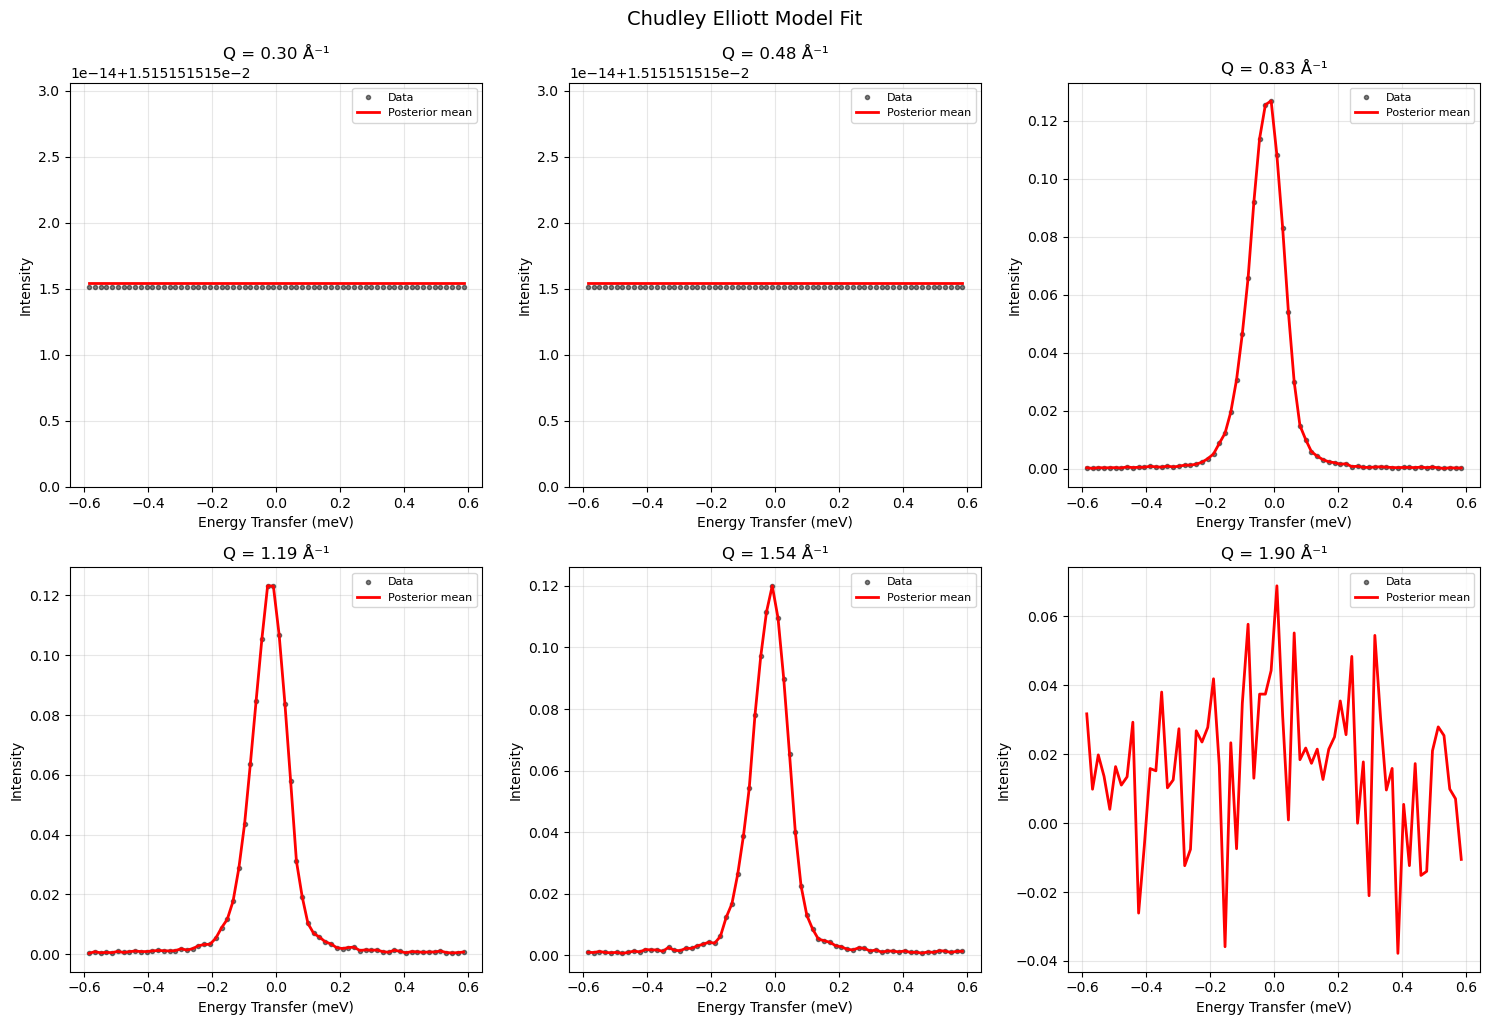

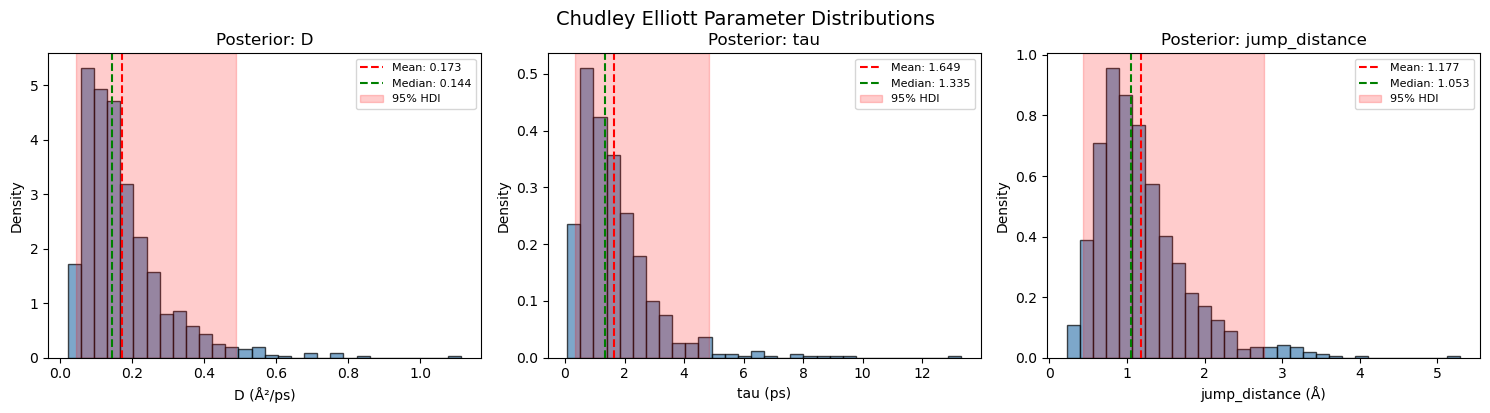

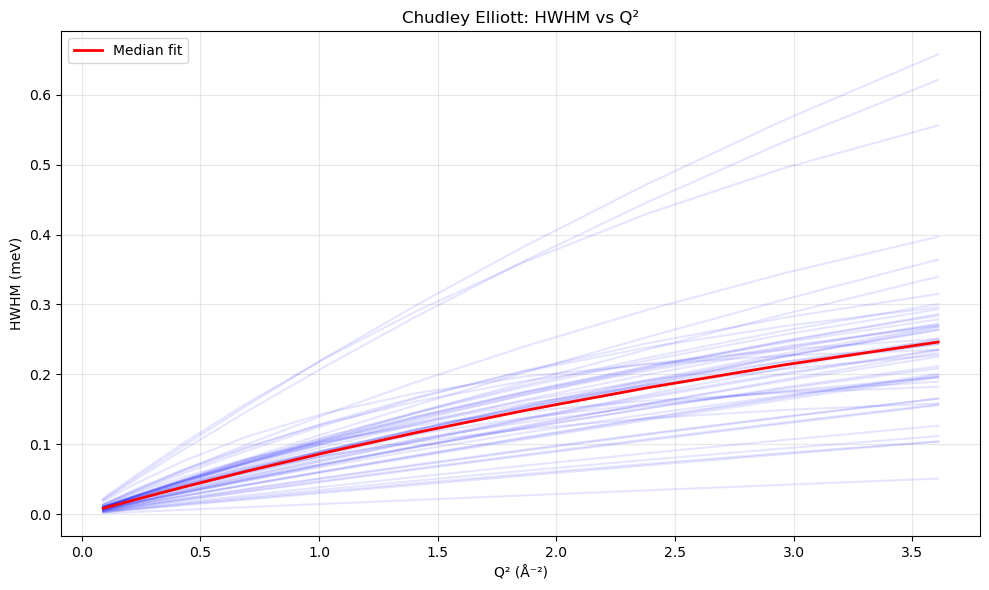


SUMMARY: Diffusion Parameters Comparison
          Model       D (Å²/ps)         J (Å)      τ (ps)
Chudley Elliott 0.1730 ± 0.1180 1.177 ± 0.587 1.65 ± 1.28

Total analysis time: 5.3 seconds


In [ ]:
def main():
    """
    Main function to run accelerated Bayesian QENS analysis
    """

    filepath = Path("/Users/shubhamshinde/Documents/Neutron Project /Data /benzene_260_360_inc.nxspe")
    
    print("Loading data...")
    nxspe_entry = load_plet_data(filepath)
    
    intensity = nxspe_entry['data/data'].nxvalue
    energy_edges = nxspe_entry['data/energy'].nxvalue
    energy = 0.5 * (energy_edges[:-1] + energy_edges[1:])
    
    if intensity.shape[0] == len(energy):
        intensity = intensity.T
    
    print(f"Original data shape: {intensity.shape}")
    print(f"Energy range: {energy[0]:.2f} to {energy[-1]:.2f} meV")
    
    # Run analysis with Chudley-Elliott model only (fastest)
    results, data = accelerated_qens_analysis(
        intensity, energy,
        max_q_points=10,
        models=['chudley_elliott']  
    )
    
    return results


if __name__ == "__main__":
    results = main()